In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/taxi-trip-pricing/taxi_trip_pricing.csv


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/taxi-trip-pricing/taxi_trip_pricing.csv")  # Load your dataset

time_counts = df['Time_of_Day'].value_counts()
time_percent = df['Time_of_Day'].value_counts(normalize=True) * 100

print("Trip distribution by Time_of_Day:\n")
print(pd.DataFrame({
    'Count': time_counts,
    'Percentage': time_percent.round(2)
}))


Trip distribution by Time_of_Day:

             Count  Percentage
Time_of_Day                   
Afternoon      371       39.05
Morning        283       29.79
Evening        203       21.37
Night           93        9.79


In [42]:

df['Price_Level'] = pd.cut(df['Trip_Price'], bins=[0, 30, 60, df['Trip_Price'].max()],
                           labels=['Low', 'Medium', 'High'])

price_counts = df['Price_Level'].value_counts()
price_percent = df['Price_Level'].value_counts(normalize=True) * 100

print("Trip_Price distribution:\n")
print(pd.DataFrame({
    'Count': price_counts,
    'Percentage': price_percent.round(2)
}))


Trip_Price distribution:

             Count  Percentage
Price_Level                   
Medium         428       45.01
High           340       35.75
Low            183       19.24


In [43]:
num_cols = ['Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']

for col in num_cols:
    print(f"\nStatistics for {col}:")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())



Statistics for Base_Fare:
Mean: 3.502989473684211
Median: 3.52
Variance: 0.7571817807109976
Standard Deviation: 0.8701619278680248

Statistics for Per_Km_Rate:
Mean: 1.2333157894736844
Median: 1.22
Variance: 0.1847416809938439
Standard Deviation: 0.4298158687087343

Statistics for Per_Minute_Rate:
Mean: 0.2929157894736842
Median: 0.29
Variance: 0.01336145760079862
Standard Deviation: 0.11559177133688461

Statistics for Trip_Duration_Minutes:
Mean: 62.11811578947369
Median: 61.86
Variance: 1033.9058553501193
Standard Deviation: 32.1544064686338

Statistics for Trip_Price:
Mean: 56.87477332571041
Median: 50.07450000000001
Variance: 1637.803947177839
Standard Deviation: 40.46979055020966


In [44]:
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Passenger_Count', 'Traffic_Conditions', 'Weather']

for col in cat_cols:
    freq = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100
    print(f"\n{col} Distribution:\n")
    print(pd.DataFrame({'Count': freq, 'Percentage': percent.round(2)}))



Time_of_Day Distribution:

             Count  Percentage
Time_of_Day                   
Afternoon      371       39.05
Morning        283       29.79
Evening        203       21.37
Night           93        9.79

Day_of_Week Distribution:

             Count  Percentage
Day_of_Week                   
Weekday        655       68.95
Weekend        295       31.05

Passenger_Count Distribution:

                 Count  Percentage
Passenger_Count                   
3.0                251       26.42
2.0                241       25.37
1.0                238       25.05
4.0                220       23.16

Traffic_Conditions Distribution:

                    Count  Percentage
Traffic_Conditions                   
Low                   397       41.79
Medium                371       39.05
High                  182       19.16

Weather Distribution:

         Count  Percentage
Weather                   
Clear      667       70.21
Rain       227       23.89
Snow        56        5.89


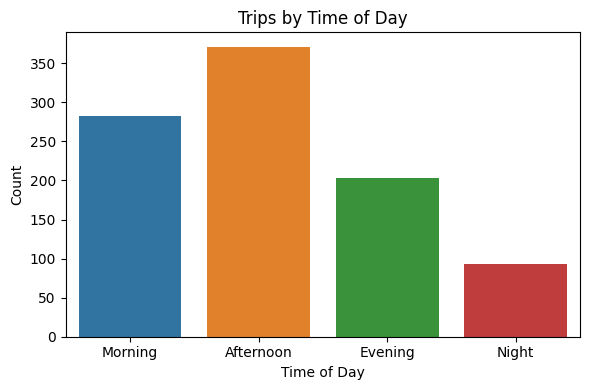

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Time_of_Day', data=df)
plt.title('Trips by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

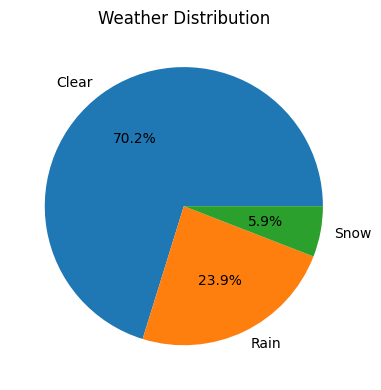

In [46]:
plt.figure(figsize=(4,4))
df['Weather'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Weather Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

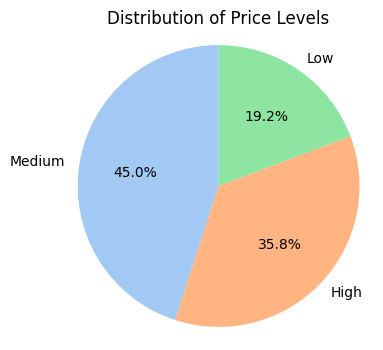

In [47]:
# Pie chart for Price_Level
price_counts = df['Price_Level'].value_counts()
plt.figure(figsize=(4,4))
plt.pie(price_counts, labels=price_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Distribution of Price Levels")
plt.axis('equal')
plt.show()


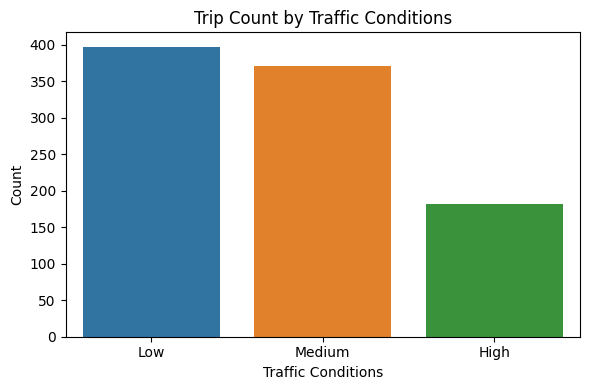

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='Traffic_Conditions', data=df, order=df['Traffic_Conditions'].value_counts().index)
plt.title("Trip Count by Traffic Conditions")
plt.xlabel("Traffic Conditions")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

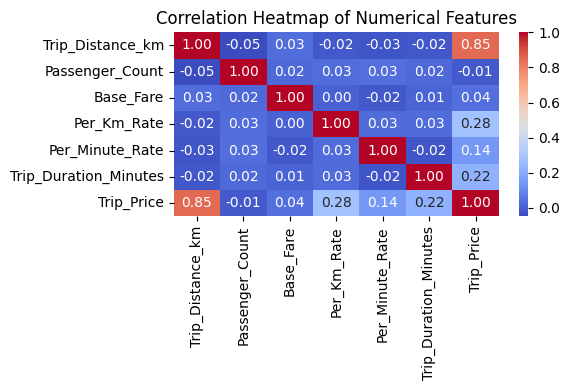

In [49]:

numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [50]:
missing_values = df.isnull().sum()

print(missing_values)

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
Price_Level              49
dtype: int64
